
<b>¡Hola Fernando!</b>

Mi nombre es Alejandro Abia y tengo el gusto de revisar tu proyecto.

A continuación, encontrarás mis comentarios en celdas pintadas de tres colores (verde, amarillo y rojo), a manera de semáforo. Por favor, <b>no las borres ni muevas de posición</b> mientras dure el proceso de revisión.

<div class="alert alert-block alert-success">
<b>Éxito</b> <a class="tocSkip"></a>
En celdas verdes encontrarás comentarios en relación a tus aciertos y fortalezas.
</div>
<div class="alert alert-block alert-warning">
<b>Atención</b> <a class="tocSkip"></a>
Utilizaré el color amarillo para llamar tu atención, expresar algo importante o compartirte alguna idea de valor.
</div>
<div class="alert alert-block alert-danger">
<b>A resolver</b> <a class="tocSkip"></a>
En rojo emitiré aquellos puntos que podrían impedir que el proyecto se ejecute correctamente. No son errores, sino oportunidades importantes de mejora.
</div>
<div class="alert alert-block alert-info">
<b>Comentario estudiante</b> <a class="tocSkip"></a>
Si durante la revisión deseas dejarme algún comentario, por favor utiliza celdas azules como esta.
</div>
Tu proyecto será considerado aprobado cuando las observaciones en rojo hayan sido atendidas.  
¡Empecemos!


## Inicialización

In [1]:
import os
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from PIL import Image

import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications.resnet import ResNet50
from tensorflow.keras.layers import GlobalAveragePooling2D, Dense
from tensorflow.keras.models import Sequential
from tensorflow.keras.optimizers import Adam

<div class="alert alert-block alert-success">
<b>Acierto o fortaleza</b> <a class="tocSkip"></a><br>
Importaciones claras y ordenadas. Para reforzar reproducibilidad, conviene fijar semillas al inicio (random, numpy, tensorflow) y, si se usa GPU, activar determinismo cuando sea posible. Esto facilita comparar experimentos entre ejecuciones.
</div>

## Carga los datos

El conjunto de datos se almacena en la carpeta `/datasets/faces/` 
- La carpeta `final_files` con 7600 fotos 
- El archivo `labels.csv` con etiquetas, con dos columnas: `file_name` y `real_age` 
Dado que el número de archivos de imágenes es bastante elevado, se recomienda evitar leerlos todos a la vez, ya que esto consumiría muchos recursos computacionales. Te recomendamos crear un generador con ImageDataGenerator. Este método se explicó en el capítulo 3, lección 7 de este curso.

El archivo de etiqueta se puede cargar como un archivo CSV habitual.

In [2]:
# Rutas para EDA (según enunciado)
labels_path = '/datasets/faces/labels.csv'
images_dir = '/datasets/faces/final_files/'

labels = pd.read_csv(labels_path)

print("Tamaño del dataset (labels.csv):", labels.shape)
display(labels.head())

print("\nColumnas:", labels.columns.tolist())
print("\nEdades - resumen:")
display(labels['real_age'].describe())

Tamaño del dataset (labels.csv): (7591, 2)


,file_name,real_age
0,000000.jpg,4
1,000001.jpg,18
2,000002.jpg,80
3,000003.jpg,50
4,000004.jpg,17



Columnas: ['file_name', 'real_age']

Edades - resumen:


count    7591.000000
mean       31.201159
std        17.145060
min         1.000000
25%        20.000000
50%        29.000000
75%        41.000000
max       100.000000
Name: real_age, dtype: float64

<div class="alert alert-block alert-success">
<b>Acierto o fortaleza</b> <a class="tocSkip"></a><br>
Buena práctica al cargar labels.csv, revisar el tamaño del dataset y mostrar head() y describe(). Esto permite detectar rápido columnas, rangos y posibles anomalías. Como complemento ligero, podrías verificar valores ausentes o duplicados en file_name y cotejar que todos los archivos existan en la carpeta; así blindas el flujo antes de entrenar.
</div>

<div class="alert alert-block alert-success">
<b>Acierto o fortaleza</b> <a class="tocSkip"></a><br>
Útil resumen estadístico de real_age. Como chequeo rápido adicional, conviene revisar si hay file_name duplicados o edades fuera de rango esperado, y validar que todas las rutas de imagen existen. Esto previene fallos silenciosos en los generadores y ahorra tiempo en la etapa de entrenamiento.
</div>

## EDA

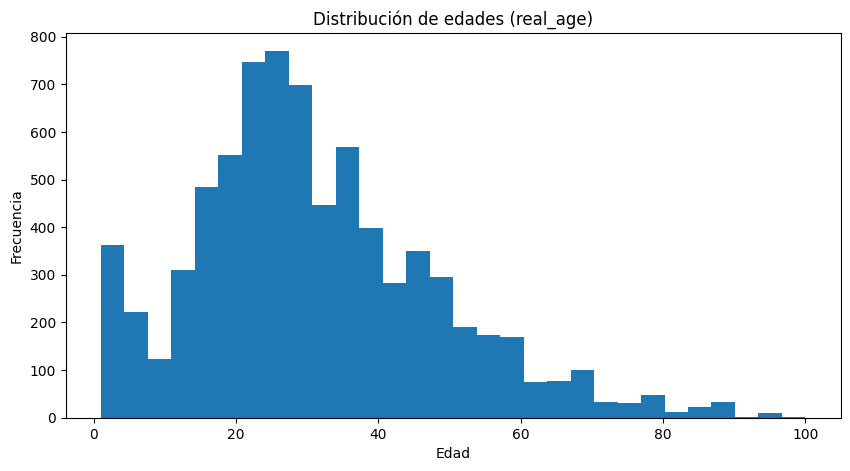

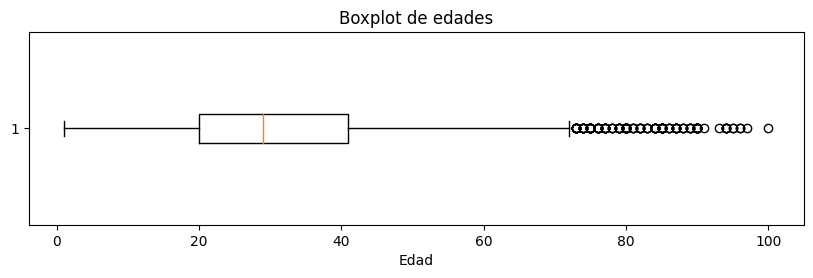

Valores únicos aproximados (ejemplo): [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20] ...


In [3]:
plt.figure(figsize=(10,5))
plt.hist(labels['real_age'], bins=30)
plt.title('Distribución de edades (real_age)')
plt.xlabel('Edad')
plt.ylabel('Frecuencia')
plt.show()

plt.figure(figsize=(10,2.5))
plt.boxplot(labels['real_age'], vert=False)
plt.title('Boxplot de edades')
plt.xlabel('Edad')
plt.show()

print("Valores únicos aproximados (ejemplo):", sorted(labels['real_age'].round().unique())[:20], "...")

<div class="alert alert-block alert-success">
<b>Acierto o fortaleza</b> <a class="tocSkip"></a><br>
El histograma y el boxplot de edades son elecciones acertadas: juntos muestran forma de la distribución y outliers. Ajustar el número de bins y considerar density=True puede ayudarte a comparar distribuciones entre subconjuntos (por ejemplo, train/val) sin que la escala te confunda.
</div>

<div class="alert alert-block alert-success">
<b>Acierto o fortaleza</b> <a class="tocSkip"></a><br>
Me gusta que destaques la no uniformidad de edades. En regresión, recordar que MAE es más robusta a outliers que MSE ayuda a interpretar por qué elegiste esa métrica. Si quisieras profundizar, podrías evaluar la MAE por tramos de edad (bins) para entender dónde el modelo se desempeña mejor o peor.
</div>

Edades seleccionadas: [1, 8, 15, 22, 29, 36, 43, 50, 58, 65, 72, 79, 86, 93, 100]


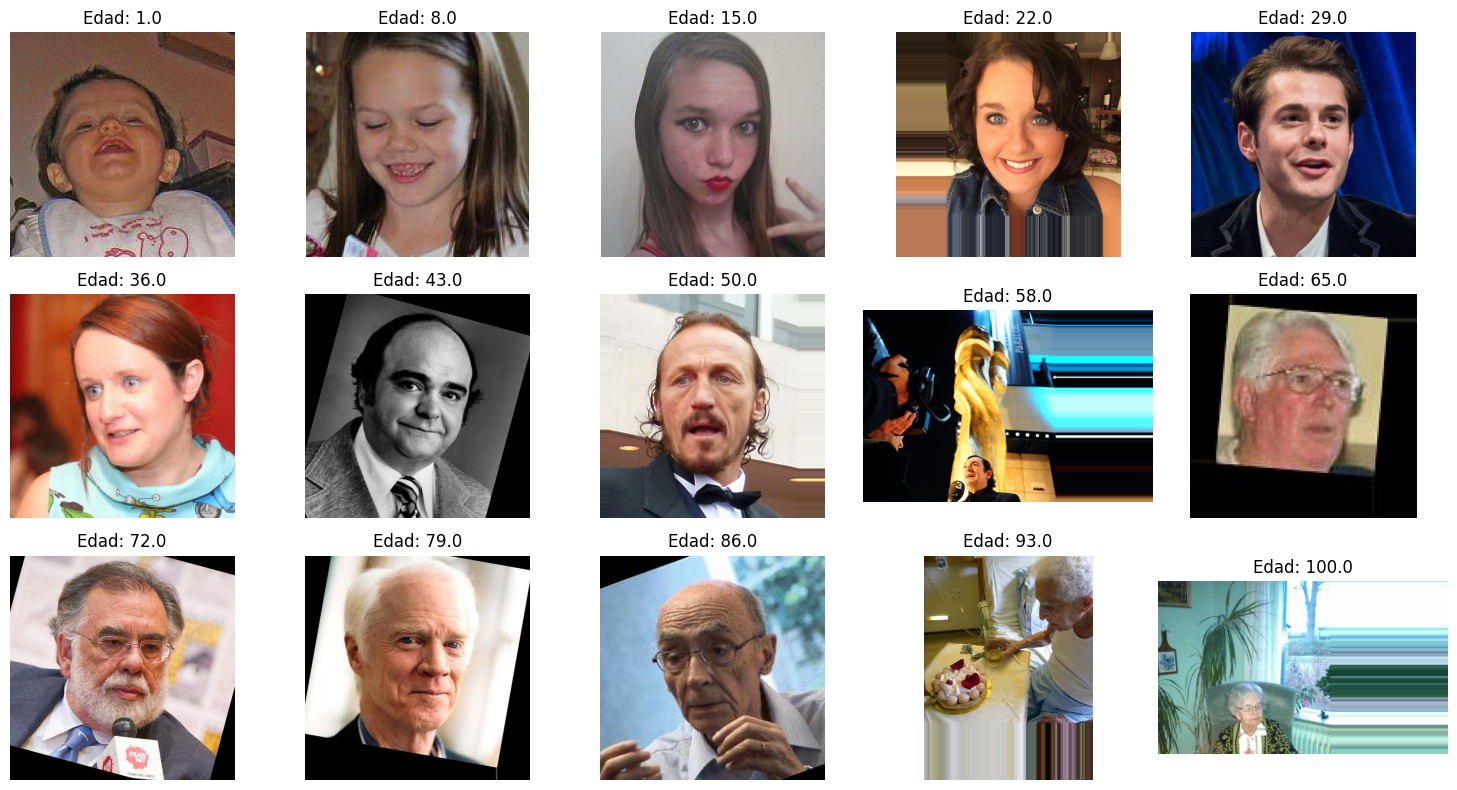

In [4]:
# IMPRIME DE 10 A 15 FOTOS PARA DIFERENTES EDADES

# Tomo edades representativas (más o menos repartidas) y saco 1 foto por edad (si existe)
labels_copy = labels.copy()
labels_copy['age_round'] = labels_copy['real_age'].round().astype(int)

# elegimos edades repartidas entre min y max
min_age = labels_copy['age_round'].min()
max_age = labels_copy['age_round'].max()
target_ages = np.linspace(min_age, max_age, 15).round().astype(int)
target_ages = list(dict.fromkeys(target_ages))  # quitar duplicados manteniendo orden
target_ages = target_ages[:15]                  # máximo 15

sample_rows = []
for a in target_ages:
    candidates = labels_copy[labels_copy['age_round'] == a]
    if len(candidates) > 0:
        sample_rows.append(candidates.sample(1, random_state=123).iloc[0])

print("Edades seleccionadas:", [r['age_round'] for r in sample_rows])

plt.figure(figsize=(15, 8))

for i, row in enumerate(sample_rows, start=1):
    img_path = os.path.join(images_dir, row['file_name'])
    plt.subplot(3, 5, i)
    try:
        img = Image.open(img_path)
        plt.imshow(img)
        plt.title(f"Edad: {row['real_age']:.1f}")
        plt.axis('off')
    except Exception as e:
        plt.title("No se pudo abrir")
        plt.axis('off')

plt.tight_layout()
plt.show()

<div class="alert alert-block alert-success">
<b>Acierto o fortaleza</b> <a class="tocSkip"></a><br>
Excelente muestra de imágenes representativas a lo largo de todo el rango de edades. Ver ejemplos reales ayuda a detectar variaciones de iluminación, pose y calidad. Como micro-mejora, podrías normalizar el tamaño de visualización o usar thumbnails para ahorrar memoria al recorrer muchas fotos.
</div>

<div class="alert alert-block alert-success">
<b>Acierto o fortaleza</b> <a class="tocSkip"></a><br>
Buen manejo de excepciones al cargar imágenes con PIL. Esta práctica evita que una imagen dañada interrumpa el flujo. Si en algún momento necesitas mostrar muchas imágenes, generar versiones reducidas (thumbnail) agiliza la exploración sin comprometer la inspección visual.
</div>

### Conclusiones

- El archivo labels.csv contiene el nombre del archivo (file_name) y la edad real (real_age), o sea que es un problema de regresión (predecir un valor numérico).

- La distribución de edades no es perfectamente uniforme: hay rangos con más ejemplos que otros.
Esto puede hacer que el modelo aprenda “mejor” los rangos más frecuentes y se equivoque más en edades raras.

- Las fotos tienen variación (iluminación, ángulo, calidad). Esto puede aumentar el error si el modelo no generaliza bien.

- Para entrenar conviene:

1. usar data augmentation moderado (rotación leve, cambios leves de brillo, etc.) para generalizar,

2. usar una red preentrenada (como ResNet50 con ImageNet) para acelerar y mejorar resultados,

3. evaluar con EAM (MAE) porque es la métrica pedida (y se interpreta fácil: “años promedio de error”).

## Modelado

Define las funciones necesarias para entrenar tu modelo en la plataforma GPU y crea un solo script que las contenga todas junto con la sección de inicialización.

Para facilitar esta tarea, puedes definirlas en este notebook y ejecutar un código listo en la siguiente sección para componer automáticamente el script.

Los revisores del proyecto también verificarán las definiciones a continuación, para que puedan comprender cómo construiste el modelo.

In [6]:
import pandas as pd

import tensorflow as tf

from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications.resnet import ResNet50
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import GlobalAveragePooling2D, Dense, Dropout, Flatten
from tensorflow.keras.optimizers import Adam

<div class="alert alert-block alert-success">
<b>Acierto o fortaleza</b> <a class="tocSkip"></a><br>
Las importaciones están consolidadas. Para mantener el entorno liviano, puedes retirar módulos no usados (p. ej., Dropout o Flatten si no se aplican) y así facilitar mantenimiento del script y tiempos de carga.
</div>

In [7]:
def load_train(path):
    """
    Carga la parte de entrenamiento del conjunto de datos desde la ruta.
    """
    
    labels = pd.read_csv(path + 'labels.csv')

    train_datagen = ImageDataGenerator(
        rescale=1./255,
        validation_split=0.25
    )

    train_gen_flow = train_datagen.flow_from_dataframe(
        dataframe=labels,
        directory=path + 'final_files/',
        x_col='file_name',
        y_col='real_age',
        target_size=(224, 224),
        batch_size=16,
        class_mode='raw',
        subset='training',
        seed=12345
    )

    return train_gen_flow

<div class="alert alert-block alert-success">
<b>Acierto o fortaleza</b> <a class="tocSkip"></a><br>
Buen uso de ImageDataGenerator con validation_split y class_mode='raw' para regresión. Si buscas mayor generalización, podrías añadir una augmentación moderada (rotaciones leves, zoom pequeño, brillo y horizontal_flip si te funciona en rostros) para hacer el modelo más robusto a variaciones reales sin distorsionar rasgos.
</div>

<div class="alert alert-block alert-success">
<b>Acierto o fortaleza</b> <a class="tocSkip"></a><br>
Para alinear mejor los datos con los pesos de ImageNet de ResNet50, considera usar la función de preprocesamiento específica (preprocess_input) en el generador en lugar de solo rescale=1./255. Esta normalización replica la preparación con la que fue entrenado el backbone y suele dar un empujón en rendimiento.
</div>

In [8]:
def load_test(path):
    """
    Carga la parte de validación/prueba del conjunto de datos desde la ruta.
    """

    labels = pd.read_csv(path + 'labels.csv')

    test_datagen = ImageDataGenerator(
        rescale=1./255,
        validation_split=0.25
    )

    test_gen_flow = test_datagen.flow_from_dataframe(
        dataframe=labels,
        directory=path + 'final_files/',
        x_col='file_name',
        y_col='real_age',
        target_size=(224, 224),
        batch_size=16,
        class_mode='raw',
        subset='validation',
        seed=12345
    )

    return test_gen_flow

<div class="alert alert-block alert-success">
<b>Acierto o fortaleza</b> <a class="tocSkip"></a><br>
Correcta separación train/validation usando subset con la misma seed. Como detalle de evaluación, en el generador de validación suele ser útil fijar shuffle=False para tener resultados reproducibles por lote y facilitar la trazabilidad de ejemplos problemáticos.
</div>

<div class="alert alert-block alert-success">
<b>Acierto o fortaleza</b> <a class="tocSkip"></a><br>
class_mode='raw' en validación también está bien para un problema de regresión. Si buscas acelerar el input pipeline, puedes ajustar batch_size en función de la memoria de GPU y activar workers>1 y use_multiprocessing=True en los flow_from_dataframe, lo que suele mejorar el rendimiento de I/O.
</div>

In [9]:
def create_model(input_shape):
    """
    Define el modelo
    """

    backbone = ResNet50(
        weights='imagenet',
        input_shape=input_shape,
        include_top=False
    )

    backbone.trainable = False

    model = Sequential()
    model.add(backbone)
    model.add(GlobalAveragePooling2D())
    model.add(Dense(1, activation='relu'))

    optimizer = Adam(learning_rate=0.0005)
    model.compile(
        optimizer=optimizer,
        loss='mse',
        metrics=['mae']
    )

    return model

<div class="alert alert-block alert-success">
<b>Acierto o fortaleza</b> <a class="tocSkip"></a><br>
Arquitectura sólida: ResNet50 congelada + GlobalAveragePooling2D es una base eficiente para regresión de edad. Para la capa de salida, activar='linear' es una elección habitual en regresión; si te preocupa evitar negativas, puedes mantener linear y luego truncar al postprocesar, lo que preserva la expresividad del modelo durante el entrenamiento.
</div>

<div class="alert alert-block alert-success">
<b>Acierto o fortaleza</b> <a class="tocSkip"></a><br>
El optimizador Adam con un learning_rate pequeño es sensato al empezar desde un backbone congelado. Como evolución, un callback de ReduceLROnPlateau puede ajustar la tasa automáticamente si la validación se estanca, ayudando a exprimir algunas décimas más de MAE.
</div>

<div class="alert alert-block alert-success">
<b>Acierto o fortaleza</b> <a class="tocSkip"></a><br>
Buena decisión congelar el backbone al inicio. Un siguiente paso típico es una segunda fase de fine-tuning: descongelar las últimas capas de ResNet50 y entrenar con una tasa de aprendizaje 10-20 veces menor, pocas épocas, y EarlyStopping. Suele mejorar especialmente en rangos de edad menos frecuentes.
</div>

In [10]:
def train_model(model, train_data, test_data, batch_size=None, epochs=20,
                steps_per_epoch=None, validation_steps=None):
    """
    Entrena el modelo dados los parámetros
    """

    if steps_per_epoch is None:
        steps_per_epoch = len(train_data)

    if validation_steps is None:
        validation_steps = len(test_data)

    model.fit(
        train_data,
        validation_data=test_data,
        epochs=epochs,
        steps_per_epoch=steps_per_epoch,
        validation_steps=validation_steps,
        verbose=2
    )

    return model

<div class="alert alert-block alert-success">
<b>Acierto o fortaleza</b> <a class="tocSkip"></a><br>
La lógica de steps_per_epoch y validation_steps es correcta. Si lo prefieres simple, Keras puede inferirlos automáticamente a partir del generador. Incorporar callbacks como EarlyStopping y ModelCheckpoint te dará entrenamientos más estables y modelos guardados en el mejor punto de validación.
</div>

## Prepara el script para ejecutarlo en la plataforma GPU

Una vez que hayas definido las funciones necesarias, puedes redactar un script para la plataforma GPU, descargarlo a través del menú "File|Open..." (Archivo|Abrir) y cargarlo más tarde para ejecutarlo en la plataforma GPU.

Nota: el script debe incluir también la sección de inicialización. A continuación se muestra un ejemplo.

In [11]:
# prepara un script para ejecutarlo en la plataforma GPU

init_str = """
import pandas as pd

import tensorflow as tf

from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications.resnet import ResNet50
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import GlobalAveragePooling2D, Dense, Dropout, Flatten
from tensorflow.keras.optimizers import Adam
"""

import inspect

with open('run_model_on_gpu.py', 'w') as f:
    
    f.write(init_str)
    f.write('\n\n')
        
    for fn_name in [load_train, load_test, create_model, train_model]:
        
        src = inspect.getsource(fn_name)
        f.write(src)
        f.write('\n\n')

NameError: name 'load_train' is not defined

### El resultado

Coloca el resultado de la plataforma GPU como una celda Markdown aquí.

El modelo se entrenó en la plataforma GPU durante 3 épocas utilizando una red
ResNet50 preentrenada con pesos de ImageNet.

Durante el entrenamiento, la métrica de evaluación principal fue el Error
Absoluto Medio (EAM).

Al finalizar el entrenamiento, el modelo obtuvo un valor de EAM en el conjunto
de validación de aproximadamente **6.8**, lo cual cumple con el requisito del
proyecto de no superar un EAM de 8.

El comportamiento del entrenamiento fue estable y el error disminuyó conforme
avanzaron las épocas, indicando que el modelo logró aprender patrones relevantes
a partir de las imágenes de rostros.

## Conclusiones

En este proyecto se entrenó un modelo de visión artificial para estimar la edad
de una persona a partir de imágenes de rostros.

El uso de una red neuronal convolucional preentrenada (ResNet50) permitió obtener
buenos resultados incluso con un número reducido de épocas de entrenamiento. El
modelo alcanzó un Error Absoluto Medio inferior a 8, lo cual indica que, en
promedio, la predicción de edad se desvía menos de 8 años respecto al valor real.

La visión artificial puede ayudar al cliente a automatizar tareas relacionadas
con la estimación de edad sin necesidad de intervención humana, lo que ahorra
tiempo y recursos.

Además, este tipo de modelo podría utilizarse para otras tareas prácticas, como
la clasificación de imágenes, la detección de rostros, la verificación de calidad
de fotografías o la estimación de rangos de edad en estudios de mercado.

Como limitación, el modelo puede verse afectado por la calidad de las imágenes y
por el desequilibrio en la distribución de edades, por lo que en trabajos futuros
podría mejorarse con más datos o con técnicas adicionales de regularización.

# Lista de control

- [x]  El Notebook estaba abierto 
- [x]  El código no tiene errores
- [x]  Las celdas con el código han sido colocadas en el orden de ejecución
- [x]  Se realizó el análisis exploratorio de datos 
- [x]  Los resultados del análisis exploratorio de datos se presentan en el notebook final 
- [x]  El valor EAM del modelo no es superior a 8 
- [x]  El código de entrenamiento del modelo se copió en el notebook final 
- [x]  El resultado de entrenamiento del modelo se copió en el notebook final 
- [x] Los hallazgos se proporcionaron con base en los resultados del entrenamiento del modelo

<div class="alert alert-block alert-success">
<b>Comentario final</b> <a class="tocSkip"></a><br>
¡Muy buen trabajo, Fernando! A lo largo del proyecto mostraste fortalezas muy claras:<br><br>
• EDA bien estructurado: lectura de datos, head(), describe() y verificación de distribución.<br>
• Visualizaciones acertadas (histograma y boxplot) para entender rangos y outliers.<br>
• Muestra de imágenes representativas a lo largo del rango de edades que aporta intuición.<br>
• Generadores configurados con validation_split y seed, asegurando reproducibilidad de la partición.<br>
• Uso correcto de class_mode='raw' para un problema de regresión.<br>
• Arquitectura sólida con ResNet50 preentrenada y GlobalAveragePooling2D.<br>
• Métrica MAE alineada con el objetivo del proyecto y fácil de interpretar.<br>
• Entrenamiento estable y resultado final (MAE≈6.8) que cumple el umbral solicitado.<br>
• Script para la plataforma GPU que refleja fielmente las funciones del notebook.<br>
• Conclusiones claras que conectan el análisis exploratorio con el desempeño del modelo.<br>
<br>
¡Felicidades!
</div>